In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [87]:
file_path = "heartrate_bmp_data.csv"
df = pd.read_csv(file_path)

In [88]:
time_array = df['Time']
current_array = df['Current']

In [39]:
TIME_WINDOW = 0.75  # seconds

In [48]:
import math

class ZScoreSmoother:
    DEFAULT_LAG = 32
    DEFAULT_THRESHOLD = 2
    DEFAULT_INFLUENCE = 0.5
    DEFAULT_EPSILON = 0.01

    def __init__(self, lag=None, threshold=None, influence=None):
        """
        lag: Number of samples to use for the moving window
        threshold: The z-score at which the algorithm signals a peak
        influence: The influence (between 0 and 1) of new signals on the mean
        """
        self.lag = lag if lag is not None else self.DEFAULT_LAG
        self.threshold = threshold if threshold is not None else self.DEFAULT_THRESHOLD
        self.influence = influence if influence is not None else self.DEFAULT_INFLUENCE

        self.EPSILON = self.DEFAULT_EPSILON
        self.index = 0
        self.peak = 0

        # Circular buffers
        self.data = [0.0] * self.lag
        self.avg = [0.0] * self.lag
        self.std = [0.0] * self.lag

    def set_epsilon(self, epsilon):
        self.EPSILON = epsilon

    def get_epsilon(self):
        return self.EPSILON

    def add(self, new_sample):
        self.peak = 0

        i = self.index % self.lag       # current index
        j = (self.index + 1) % self.lag # next index

        deviation = new_sample - self.avg[i]

        if deviation > self.threshold * self.std[i]:
            self.data[j] = (
                self.influence * new_sample +
                (1.0 - self.influence) * self.data[i]
            )
            self.peak = 1

        elif deviation < -self.threshold * self.std[i]:
            self.data[j] = (
                self.influence * new_sample +
                (1.0 - self.influence) * self.data[i]
            )
            self.peak = -1

        else:
            self.data[j] = new_sample

        self.avg[j] = self._get_avg(j, self.lag)
        self.std[j] = self._get_std(j, self.lag)

        self.index += 1
        if self.index >= 16383:
            self.index = self.lag + j

        return self.std[j]

    def get_filtered(self):
        return self.avg[self.index % self.lag]

    def get_peak(self):
        return self.peak

    def _get_avg(self, start, length):
        total = 0.0
        for i in range(length):
            total += self.data[(start + i) % self.lag]
        return total / length

    def _get_point(self, start, length):
        total = 0.0
        for i in range(length):
            x = self.data[(start + i) % self.lag]
            total += x * x
        return total / length

    def _get_std(self, start, length):
        mean = self._get_avg(start, length)
        mean_sq = self._get_point(start, length)

        variance = mean_sq - (mean * mean)

        if -self.EPSILON < variance < self.EPSILON:
            return -self.EPSILON if variance < 0.0 else self.EPSILON

        return math.sqrt(variance)
    def update(self, new_sample):
        self.add(new_sample)
        return (
            new_sample,
            self.get_peak(),
            self.get_filtered()
        )



In [77]:
class FloorTracker:
    def __init__(self, alpha):
        self.alpha = alpha
        self.value = None

    def update(self, x):
        x = abs(x)

        if self.value is None:
            self.value = x
        else:
            if x < self.value:
                self.value = (1 - self.alpha) * self.value + self.alpha * x
            else:
                self.value = self.value  # peaks do not move the floor

        return max(self.value, 1e-12)


In [67]:
class SlowBaseline:
    def __init__(self, alpha):
        self.alpha = alpha
        self.value = 0.0
        self.initialized = False

    def update(self, x):
        if not self.initialized:
            self.value = x
            self.initialized = True
        else:
            self.value = (1 - self.alpha) * self.value + self.alpha * x
        return self.value
class EnvelopeTracker:
    def __init__(self, alpha):
        self.alpha = alpha
        self.env = 0.0

    def update(self, x):
        mag = abs(x)
        self.env = (1 - self.alpha) * self.env + self.alpha * mag
        return max(self.env, 1e-12)


In [78]:
class PeakDetector:
    def __init__(self, min_height, min_interval_sec, fs):
        self.min_height = min_height
        self.min_interval = min_interval_sec
        self.fs = fs

        self.prev2 = 0.0
        self.prev1 = 0.0
        self.last_peak_time = -1e9
        self.index = 0

    def update(self, x):
        peak = False
        t = self.index / self.fs

        if self.prev2 < self.prev1 > x:
            if self.prev1 > self.min_height:
                if (t - self.last_peak_time) > self.min_interval:
                    peak = True
                    self.last_peak_time = t

        self.prev2 = self.prev1
        self.prev1 = x
        self.index += 1

        return peak


Total Peaks Detected: 221


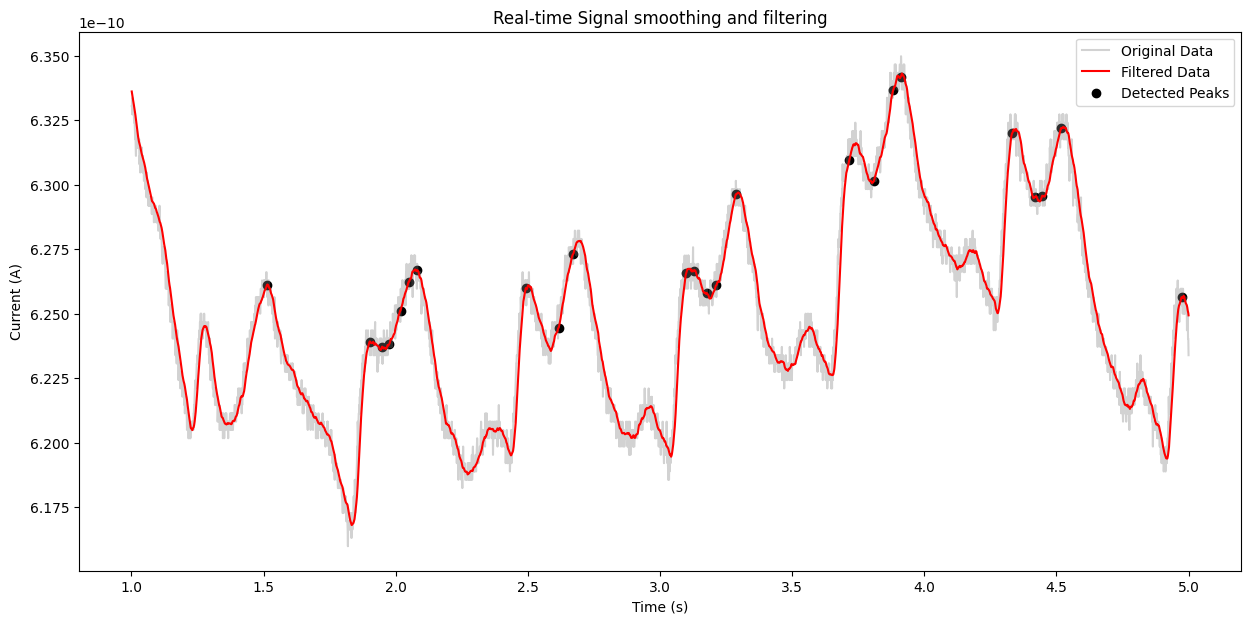

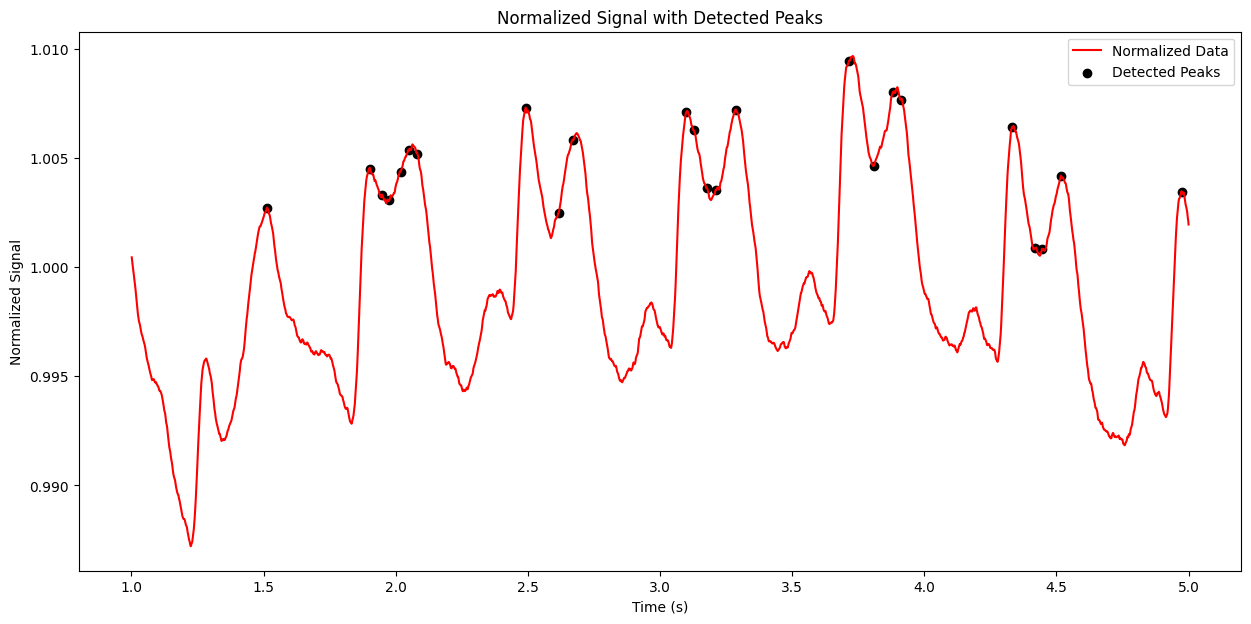

In [89]:
filtered = []
peaks = []
original = []
times = []
smoother_1 = ZScoreSmoother(lag=3, threshold=1, influence=0.01)
smoother_2 = ZScoreSmoother(lag=15, threshold=2, influence=0.001)

floor_tracker = FloorTracker(alpha=0.002)
env_tracker = EnvelopeTracker(alpha=0.005)

normalized = []

peak_detector = PeakDetector(
    min_height=1,        # tune this (relative to filtered scale)
    min_interval_sec=0.25, # max 240 BPM
    fs= 100 # 5 hz sampling rate
)

for time, current in zip(time_array, current_array):

    sample, _, filt1 = smoother_1.update(current)
    sample, _, filt2 = smoother_2.update(filt1)

    floor = floor_tracker.update(filt2)
    signal_pos = abs(filt2) - floor
    signal_pos = max(signal_pos, 0.0)

    envelope = env_tracker.update(signal_pos)
    signal_norm = signal_pos / envelope

    is_peak = peak_detector.update(signal_norm)
    normalized.append(signal_norm)
    filtered.append(filt2)
    peaks.append(1 if is_peak else 0)
    original.append(current)
    times.append(time)    

peaks = np.array(peaks)
print(f"Total Peaks Detected: {np.sum(peaks)}")
WINDOW_MAX= 5000
WINDOW_MIN= 1000
plt.figure(figsize=(15, 7))
plt.plot(times[WINDOW_MIN:WINDOW_MAX], original[WINDOW_MIN:WINDOW_MAX], label='Original Data', color='grey', alpha=0.35)
plt.plot(times[WINDOW_MIN:WINDOW_MAX], filtered[WINDOW_MIN:WINDOW_MAX], label='Filtered Data', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Current (A)')
plt.scatter(
    [times[i] for i in range(WINDOW_MIN, WINDOW_MAX) if peaks[i] != 0],
    [filtered[i] for i in range(WINDOW_MIN, WINDOW_MAX) if peaks[i] != 0],
    color='black',
    label='Detected Peaks'
)
plt.legend()
plt.title('Real-time Signal smoothing and filtering')

plt.figure(figsize=(15, 7))
plt.plot(times[WINDOW_MIN:WINDOW_MAX], normalized[WINDOW_MIN:WINDOW_MAX], label='Normalized Data', color='red')
plt.xlabel('Time (s)')
plt.ylabel('Normalized Signal')
plt.scatter(
    [times[i] for i in range(WINDOW_MIN, WINDOW_MAX) if peaks[i] != 0],
    [normalized[i] for i in range(WINDOW_MIN, WINDOW_MAX) if peaks[i] != 0],
    color='black',
    label='Detected Peaks'
)
plt.legend()
plt.title('Normalized Signal with Detected Peaks')
plt.show()


C:\Users\shash\AppData\Local\Temp\ipykernel_55604\980096264.py:45: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(


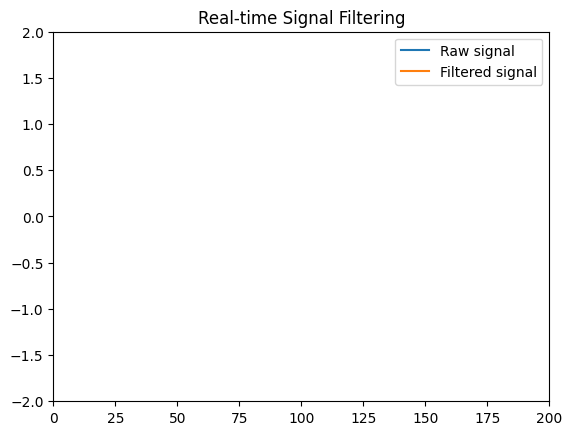

In [ ]:
import math
import random
import matplotlib.pyplot as plt
import matplotlib.animation as animation

# ---- Streaming + animation ----
detector = ZScoreSmoother(lag=10)

raw_data = []
filtered_data = []
x_vals = []

t = 0

fig, ax = plt.subplots()
raw_line, = ax.plot([], [], label="Raw signal")
filt_line, = ax.plot([], [], label="Filtered signal")

ax.set_xlim(0, 200)
ax.set_ylim(-2, 2)
ax.legend()
ax.set_title("Real-time Signal Filtering")

def update(frame):
    global t

    current = current_array.iloc[t]
    sample, peak, filt = detector.update(current)

    raw_data.append(sample)
    filtered_data.append(filt)
    x_vals.append(time_array.iloc[t])

    # Keep window moving
    if len(x_vals) > 200:
        raw_data.pop(0)
        filtered_data.pop(0)
        x_vals.pop(0)

    raw_line.set_data(x_vals, raw_data)
    filt_line.set_data(x_vals, filtered_data)

    return raw_line, filt_line

ani = animation.FuncAnimation(
    fig,
    update,
    interval=50,   # ms between samples
    blit=True
)

plt.show()


In [57]:
current_array.iloc[0]

np.float64(6.163054e-10)